In [ ]:
import sys 
sys.path.append("../../src/")
from project_imports import *
import numerical_quenches as nq 
from numerical_quenches import groundstate
import analytical_quench_states as kz
import TFIM_operators_from_states as op
import kibble_zurek as legacy 

In [148]:
L = 1000
taus = np.logspace(-1,4,100)
states = [kz.state(L,tau,tau) for tau in tqdm(taus)]

100%|██████████| 100/100 [23:41<00:00, 14.22s/it] 


# Dillute Gas approximation Breakdown

here we will explore $\log ( \braket{P_n}- \braket{P_{2}}^{n-1} )$ First with the normal quench then with the ferro-> paramangetic


In [ ]:

data = {
    "taus": np.array(taus),
    "states": states
}

#np.save("kz_states_L1000.npy", data, allow_pickle=True)

In [351]:
def P_array(ns,states):
    return array([[op.Px_n(ni,s) for s in states] for ni in tqdm(ns)])

n = [ 2, 3, 4, 5, 6, 7, 8,9,10,11,12,13,14]

In [352]:
Ps =P_array(n,states)

 62%|██████▏   | 8/13 [00:10<00:09,  1.88s/it]

KeyboardInterrupt: 

In [160]:
gs = nq.groundstate(0,L)

ol = nq.overlap(states,gs)

[]

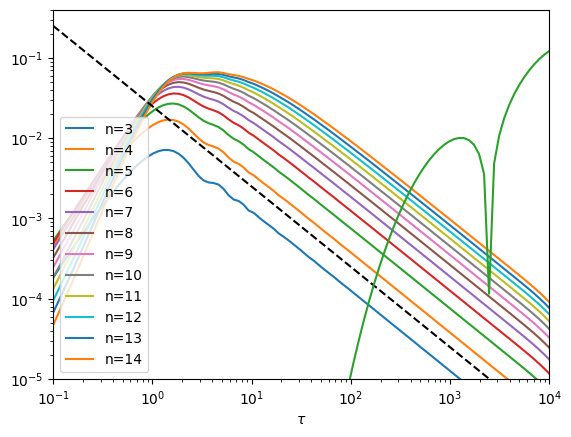

In [161]:
P2 = Ps[0]
for j in range(1,len(n)):
    P = Ps[j]

    plot(taus,np.abs(2*P-(2*P2)**(n[j]-1)),label=f"n={n[j]}")
legend(loc="lower left")
xlim(taus[0],taus[-1])
plot(taus,taus**(-1)/40,"--k")
plot(taus,np.abs(ol-(2*P2)**(L-1)))
ylim(10e-6,.4)
xlabel(r"$\tau$")
loglog()

# Rate functions

[]

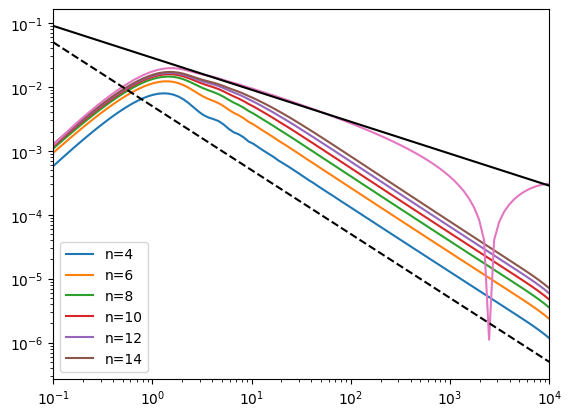

In [181]:
P2 = Ps[0]
for j in range(2,len(n),2):
    P = Ps[j]

    plot(taus,abs(-log(P*2)/(n[j]-1)- (-log(P2*2))),label=f"n={n[j]}")
legend(loc="lower left")
xlim(taus[0],taus[-1])
plot(taus,abs(-log(ol)/(L-1)- (-log(P2*2))))
#ylim(10e-6,.4)
plot(taus,taus**(-1)/200,"--k")
plot(taus,taus**(-1/2)/35,"k")

loglog()

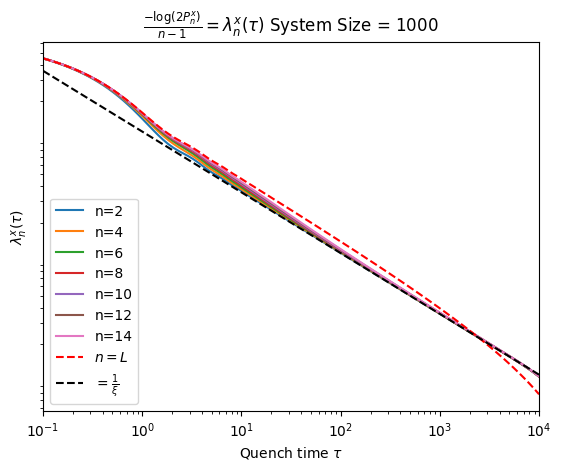

In [274]:
P2 = Ps[0]
for j in range(0,len(n),2):
    P = Ps[j]

    plot(taus,-log(2*P)/(n[j]-1),label=f"n={n[j]}")
xlim(taus[0],taus[-1])
plot(taus,-log(ol)/L,"--r",label=r"$n=L$")
#ylim(10e-6,.4)
xlabel(r"Quench time $\tau$")
title(r"$\frac{-\log(2 P^x_n)}{n-1}= \lambda^x_n(\tau)$"+ f" System Size = {L}")
ylabel(r"$\lambda^x_n(\tau)$")

xi = sqrt(2*taus)*2*pi
plot(taus,1/xi,"--k",label=r"$=\frac{1}{\xi}$")
#plot(taus,taus**(-1/2)/35,"k")
legend(loc="lower left")

loglog("log")

Text(0.5, 1.0, '$|\\lambda^x_n(\\tau) - \\lambda^x_2(\\tau)|$')

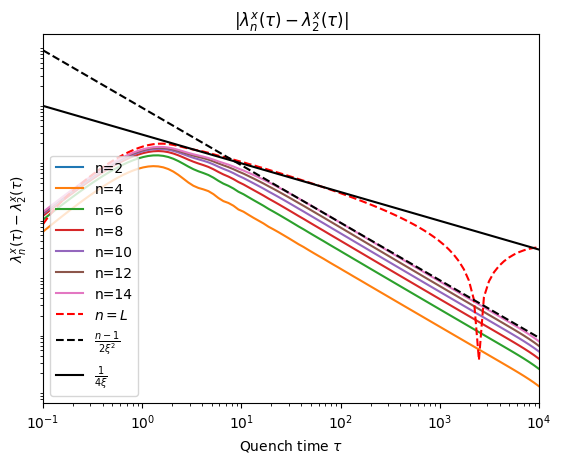

In [298]:
P2 = -log(2*Ps[0])
for j in range(0,len(n),2):
    P = Ps[j]

    plot(taus,abs(-log(2*P)/(n[j]-1)-P2),label=f"n={n[j]}")
xlim(taus[0],taus[-1])
plot(taus,abs(-log(ol)/L-P2),"--r",label=r"$n=L$")
title(r"$$")
xi = sqrt(2*taus)*2*pi
plot(taus,13/(xi)**2/2,"--k",label=r"$\frac{n-1}{2 \xi^2}$")
plot(taus,1/xi/2/2,"k",label=r"$\frac{1}{4 \xi }$")
legend(loc="lower left")

xlabel(r"Quench time $\tau$ ")
ylabel(r"$\lambda^x_n(\tau) - \lambda^x_2(\tau)$")
loglog("log")
title(r"$|\lambda^x_n(\tau) - \lambda^x_2(\tau)|$")

Text(0.5, 1.0, '$|\\lambda^x_n(\\tau) - \\lambda^x_2(\\tau)|$')

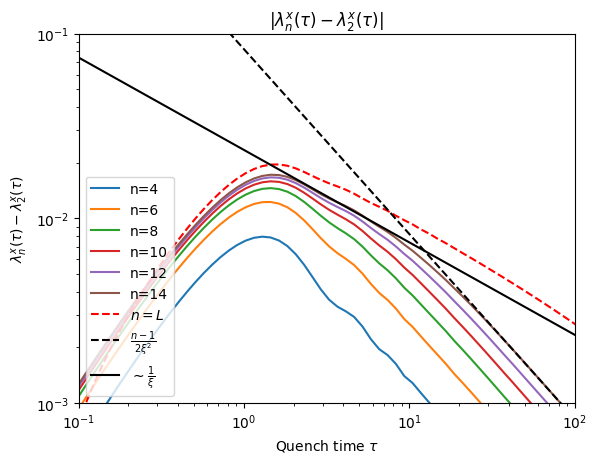

In [302]:
P2 = -log(2*Ps[0])
for j in range(2,len(n),2):
    P = Ps[j]

    #plot(taus,abs(-log(2*P)/(n[j]-1)-P2),label=f"n={n[j]}")
    plot(taus,abs(-log(2*P)/(n[j]-1)-P2),label=f"n={n[j]}")

xlim(taus[0],taus[-1])
plot(taus,abs(-log(ol)/L-P2),"--r",label=r"$n=L$")
#ylim(10e-6,.4)
xi = sqrt(2*taus)*2*pi
plot(taus,13/(xi)**2/2,"--k",label=r"$\frac{n-1}{2 \xi^2}$")
plot(taus,1/xi/4/1.2,"k",label=r"$\sim\frac{1}{ \xi }$")
legend(loc="lower left")

xlabel(r"Quench time $\tau$ ")
ylabel(r"$\lambda^x_n(\tau) - \lambda^x_2(\tau)$")
loglog("log")

xlim(taus[0],100)
ylim(10e-4,.1)

xlabel(r"Quench time $\tau$ ")
ylabel(r"$\lambda^x_n(\tau) - \lambda^x_2(\tau)$")
loglog("log")
title(r"$|\lambda^x_n(\tau) - \lambda^x_2(\tau)|$")

Text(0.5, 1.0, '$|\\lambda^x_n(\\tau) - \\lambda^x_2(\\tau)|$')

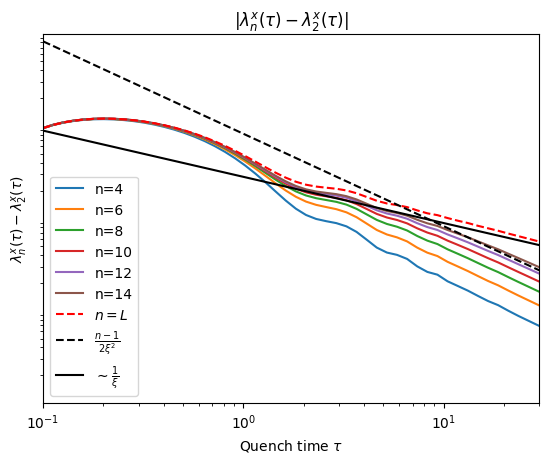

In [350]:
P2 = -log(2*Ps[0])
for j in range(2,len(n),2):
    P = Ps[j]

    #plot(taus,abs(-log(2*P)/(n[j]-1)-P2),label=f"n={n[j]}")
    plot(taus,abs(-log(2*P)/(n[j]-1)-1/xi),label=f"n={n[j]}")

plot(taus,abs(-log(ol)/L-1/xi),"--r",label=r"$n=L$")
#ylim(10e-6,.4)
xi = sqrt(2*taus)*2*pi
plot(taus,13/(xi)**2/2,"--k",label=r"$\frac{n-1}{2 \xi^2}$")
plot(taus,1/xi/4,"k",label=r"$\sim\frac{1}{ \xi }$")
legend(loc="lower left")

xlim(taus[0],30)
ylim(10e-5,1)

xlabel(r"Quench time $\tau$ ")
ylabel(r"$\lambda^x_n(\tau) - \lambda^x_2(\tau)$")
loglog("log")
title(r"$|\lambda^x_n(\tau) - \lambda^x_2(\tau)|$")

[]

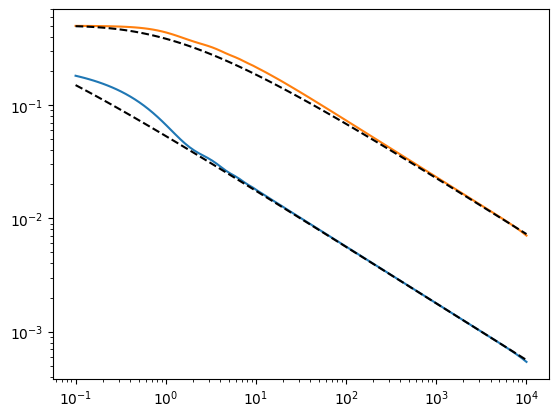

In [325]:
plot(taus,1/2-Ps[0])
plot(taus,1/2-1/2*(exp(-(1)/xi)),"--k")
loglog()

plot(taus,1/2-Ps[-1])
plot(taus,1/2-1/2*(exp(-(14-1)/xi)),"--k")
loglog()

[]

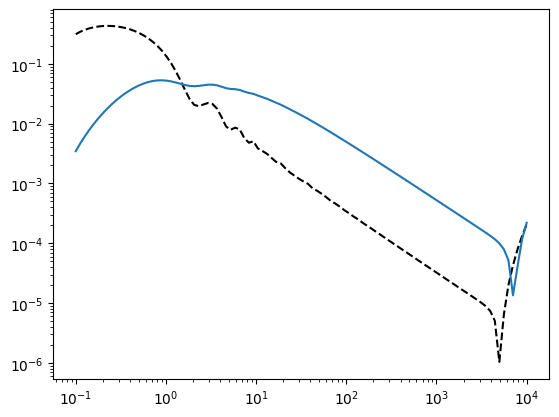

In [334]:
plot(taus,10*abs(Ps[0]-1/2*(exp(-(1)/xi))),"--k")
loglog()
plot(taus,abs(Ps[-1]-1/2*(exp(-(13)/xi))))
loglog()

In [384]:
L = 500
taus = np.logspace(np.log10(1.5),np.log10(6),100)
states = [kz.state(L,tau,tau) for tau in tqdm(taus)]

100%|██████████| 100/100 [01:06<00:00,  1.49it/s]


In [385]:
n = [ 2, 3, 4, 5, 6, 7, 8,9,10,11,12,13,14]
Ps =P_array(n,states)


100%|██████████| 13/13 [14:00<00:00, 64.66s/it] 


Text(0.5, 1.0, '$|\\lambda^x_n(\\tau) - \\lambda^x_2(\\tau)|$')

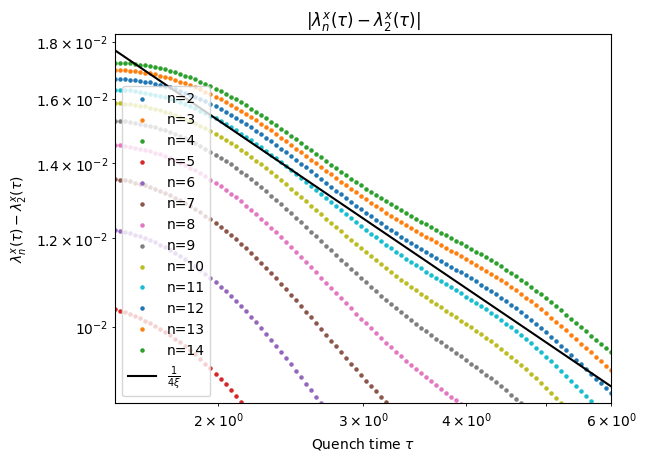

In [386]:
P2 = -log(2*Ps[0])
for j in range(0,len(n)):
    P = Ps[j]

    scatter(taus,abs(-log(2*P)/(n[j]-1)-P2),label=f"n={n[j]}",s=5)
xlim(taus[0],taus[-1])
#plot(taus,abs(-log(ol)/L-P2),"--r",label=r"$n=L$")
title(r"$$")
xi = sqrt(2*taus)*2*pi
#plot(taus,11/(xi)**2/2,"--k",label=r"$\frac{n-1}{2 \xi^2}$")
plot(taus,1/xi/2/2/1.3,"k",label=r"$\frac{1}{4 \xi }$")
legend(loc="lower left")

xlabel(r"Quench time $\tau$ ")
ylabel(r"$\lambda^x_n(\tau) - \lambda^x_2(\tau)$")
loglog("log")
title(r"$|\lambda^x_n(\tau) - \lambda^x_2(\tau)|$")